# CiteScope — Modelado · Fase 2: Baseline (solo contexto)

**Objetivo.** Establecer una referencia mínima de clasificación usando **únicamente** el `citation_context`, sin los metadatos del artículo citado. Sirve como piso frente al cual medir el aporte del enriquecimiento en la Fase 3.

**Entregables de esta fase.**
- Pipeline **TF-IDF + clasificador lineal** sobre `text_context`.
- Comparación **Logistic Regression vs. LinearSVC** en el conjunto de **validación**.
- Métricas: **Macro F1** (principal), accuracy y F1 por clase; matriz de confusión del mejor modelo.
- Resultados registrados en una tabla reproducible (`models/artifacts/baseline_results.csv`) para re-instrumentar con MLflow más adelante.

> El conjunto de **test se mantiene intacto** hasta la decisión final (Fase 4). Aquí se entrena en `train` y se evalúa en `val`. Se reutiliza el split anti-fuga de la Fase 1 (`split_assignment.csv`), con la misma semilla.


## Carga de datos y split

Cargamos el dataset (copia local verificada o el archivo canónico de DVC) y le adjuntamos la partición `train/val/test` desde `models/artifacts/split_assignment.csv`, generada en la Fase 1. Reconstruimos `text_context` (solo el contexto de la cita).


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
TARGET = "citing_primary_category"

REPO_ROOT = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Dataset"
ARTIFACTS_DIR = Path.cwd() / "artifacts"

CANONICAL = DATASET_DIR / "unarxive_microproyecto.jsonl"
LOCAL_COPY = DATASET_DIR / "copy_unarxive_microproyecto.jsonl"
DATA_PATH = CANONICAL if CANONICAL.exists() else LOCAL_COPY

df = pd.read_json(DATA_PATH, lines=True, dtype={"citing_arxiv_id": "string"})
df["text_context"] = df["citation_context"].fillna("").astype(str).str.strip()

# Adjuntar la partición generada en la Fase 1
split_map = pd.read_csv(ARTIFACTS_DIR / "split_assignment.csv")[["citation_id", "split"]]
df = df.merge(split_map, on="citation_id", how="left")
assert df["split"].notna().all(), "Hay registros sin partición asignada."

X = {name: g["text_context"] for name, g in df.groupby("split")}
yv = {name: g[TARGET] for name, g in df.groupby("split")}

print("Registros por partición:")
print(df["split"].value_counts().reindex(["train", "val", "test"]).to_string())


Registros por partición:
split
train    2400
val       800
test      800


## Vectorización y modelos baseline

Definimos un pipeline **TF-IDF → clasificador lineal** y comparamos dos clasificadores clásicos sobre texto:

- **Logistic Regression** (multinomial, probabilístico — útil luego para el `confidence` del tablero).
- **LinearSVC** (SVM lineal, típicamente fuerte en clasificación de texto).

Vectorización TF-IDF con unigramas + bigramas, `min_df=3` y `sublinear_tf=True`. Todo con la semilla fija.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def make_pipeline(classifier):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
        ("clf", classifier),
    ])


models = {
    "logreg": make_pipeline(LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    "linearsvc": make_pipeline(LinearSVC(C=1.0, random_state=SEED)),
}

print("Pipelines definidos:", ", ".join(models))


Pipelines definidos: logreg, linearsvc


## Entrenamiento y evaluación en validación

Entrenamos cada modelo en `train` y lo evaluamos en `val`. La métrica principal es **Macro F1** (trata por igual a las 8 clases balanceadas). Como referencia, el azar en 8 clases balanceadas es 12,5%.


In [6]:
from sklearn.metrics import accuracy_score, f1_score

results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X["train"], yv["train"])
    pred = pipe.predict(X["val"])
    macro_f1 = f1_score(yv["val"], pred, average="macro")
    acc = accuracy_score(yv["val"], pred)
    results.append({"modelo": name, "input": "text_context", "macro_f1_val": macro_f1, "accuracy_val": acc})
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values("macro_f1_val", ascending=False).reset_index(drop=True)
best_name = results_df.loc[0, "modelo"]
print("Resultados en validación:")
print(results_df.to_string(index=False))
print(f"\nMejor modelo: {best_name}")


Resultados en validación:
   modelo        input  macro_f1_val  accuracy_val
   logreg text_context      0.569611       0.57125
linearsvc text_context      0.552305       0.55875

Mejor modelo: logreg


## Reporte por clase y matriz de confusión

Para el mejor modelo, revisamos el F1 por subárea y la matriz de confusión en validación. Esto identifica las categorías más difíciles y las confusiones entre áreas cercanas (p. ej. `cs.AI`, `cs.LG`, `cs.NE`).


Matplotlib is building the font cache; this may take a moment.


Reporte de clasificación en validación — logreg:

              precision    recall  f1-score   support

       cs.AI      0.440     0.440     0.440       100
       cs.CL      0.670     0.650     0.660       100
       cs.CV      0.591     0.650     0.619       100
       cs.IR      0.583     0.630     0.606       100
       cs.LG      0.341     0.290     0.314       100
       cs.MA      0.637     0.650     0.644       100
       cs.NE      0.544     0.620     0.579       100
       cs.RO      0.762     0.640     0.696       100

    accuracy                          0.571       800
   macro avg      0.571     0.571     0.570       800
weighted avg      0.571     0.571     0.570       800



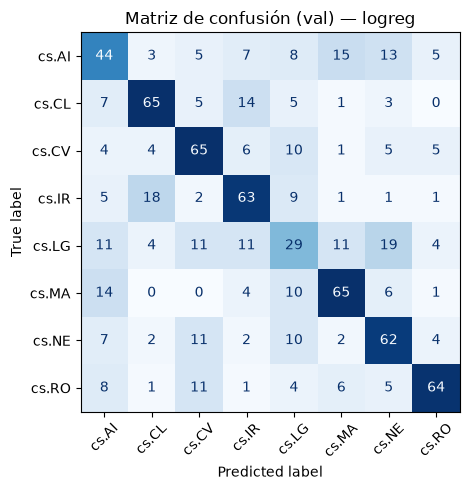

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_model = fitted[best_name]
val_pred = best_model.predict(X["val"])
labels = sorted(yv["train"].unique())

print(f"Reporte de clasificación en validación — {best_name}:\n")
print(classification_report(yv["val"], val_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    yv["val"], val_pred, labels=labels, xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax
)
ax.set_title(f"Matriz de confusión (val) — {best_name}")
plt.tight_layout()
plt.show()


## Registro de resultados

Guardamos las métricas del baseline en `models/artifacts/baseline_results.csv`. Es la tabla determinista que luego re-instrumentaremos en MLflow (Fase 5) sin repetir el trabajo exploratorio.


In [8]:
ARTIFACTS_DIR.mkdir(exist_ok=True)

results_out = results_df.assign(
    tfidf_ngram="(1, 2)", tfidf_min_df=3, sublinear_tf=True, seed=SEED, eval_split="val",
)
results_path = ARTIFACTS_DIR / "baseline_results.csv"
results_out.to_csv(results_path, index=False)

print(f"Resultados guardados en: {results_path.relative_to(REPO_ROOT)}")
results_out


Resultados guardados en: models/artifacts/baseline_results.csv


,modelo,input,macro_f1_val,accuracy_val,tfidf_ngram,tfidf_min_df,sublinear_tf,seed,eval_split
0,logreg,text_context,0.569611,0.57125,"(1, 2)",3,True,42,val
1,linearsvc,text_context,0.552305,0.55875,"(1, 2)",3,True,42,val
